# Stationarity & Differencing

In Lesson 04, we learned how to measure the "memory" of a time series using ACF and PACF. But before we can feed that memory into a classical forecasting model like ARIMA, we face a massive mathematical roadblock.

If a time series is trending upward over time, its average value today is mathematically different from its average value last year. If the fundamental statistics of the data are constantly mutating, **an algorithm cannot learn a reliable mathematical rule**. It assumes the future will act like the past, but the baseline keeps shifting!

To solve this, we must temporarily destroy the trend and mathematically force the dataset to behave. This concept is called **Stationarity**, and it is the prerequisite for almost all classical time series forecasting.

A time series is considered **Strictly Stationary** if its statistical properties do not depend on the specific time at which the series is observed.

Let's set up our Python environment to test and mathematically flatten our temporal data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Stationarity Diagnostics & Transformation Environment Ready.")

✅ Stationarity Diagnostics & Transformation Environment Ready.


# 1. The Mathematics of Stationarity

For a time series $y_t$ to be considered weakly stationary (the enterprise standard), it must mathematically satisfy three strict rules:

1. **Constant Mean ($\mu$)**: The average value of the series does not change over time. (No upward or downward trends).
2. **Constant Variance ($\sigma^2$)**: The spread or amplitude of the data does not change over time. (No multiplicative seasonality or exploding volatility).
3. **Constant Autocovariance**: The relationship between $y_t$ and $y_{t-k}$ depends *only* on the distance between them ($k$), not on the actual time $t$.

If your data violates *any* of these three rules, algorithms like ARIMA will mathematically fail to converge or will produce highly confident, entirely incorrect forecasts.

# 2. The Augmented Dickey-Fuller (ADF) Test

You cannot simply eyeball a graph to determine if it is stationary. You must use a rigorous statistical test. The industry standard is the **Augmented Dickey-Fuller (ADF) Test**.

The ADF test looks for a "Unit Root" in the data (a mathematical characteristic of unpredictable random walks).
It frames the math as a Hypothesis Test:

* **Null Hypothesis ($H_0$)**: The data has a unit root. It is **Non-Stationary**.
* **Alternative Hypothesis ($H_A$)**: The data does not have a unit root. It is **Stationary**.

If the resulting **p-value is less than 0.05**, we mathematically reject the Null Hypothesis and declare the data safe for modeling.

# 3. Differencing: The Mathematical Fix

If our data fails the ADF test, how do we fix it? We use **Differencing**.

Instead of trying to predict the *absolute value* of the stock price or the daily sales, we predict the **change** between today and yesterday.

### First-Order Differencing ($d=1$)

We subtract the previous observation from the current observation:


$$y'_t = y_t - y_{t-1}$$


If a company's revenue is growing by exactly $\$100$ every single day (a strict linear trend), the raw data will look like a steep staircase ($100, 200, 300, 400$).
If we take the First Difference, the dataset becomes ($100, 100, 100$). The trend is completely destroyed, the mean is perfectly constant at $100$, and the data is now **Stationary**!

### Second-Order Differencing ($d=2$)

If the trend is exponential (growing faster and faster), First-Order differencing will not be enough. We must difference the already-differenced data (calculating the momentum of the momentum).


$$y''_t = y'_t - y'_{t-1} = (y_t - y_{t-1}) - (y_{t-1} - y_{t-2})$$

$$y''_t = y_t - 2y_{t-1} + y_{t-2}$$

*(Note: In enterprise forecasting, it is incredibly rare to difference data more than twice. If $d=3$, you have likely over-differenced, turning your data into pure, unlearnable mathematical noise).*

# 4. Stationarity in Code

Let's simulate a non-stationary business metric (a Random Walk with an upward drift). We will run the ADF test, mathematically difference the data, and run the test again to prove we fixed it.

--- ADF Test: Raw Sales Data ---
Test Statistic: 0.4800
P-Value:        0.9843
❌ Result: NON-STATIONARY (Do not model this)

--- ADF Test: First-Order Differenced Sales ---
Test Statistic: -14.6918
P-Value:        0.0000
🚨 Result: STATIONARY (Safe to model)



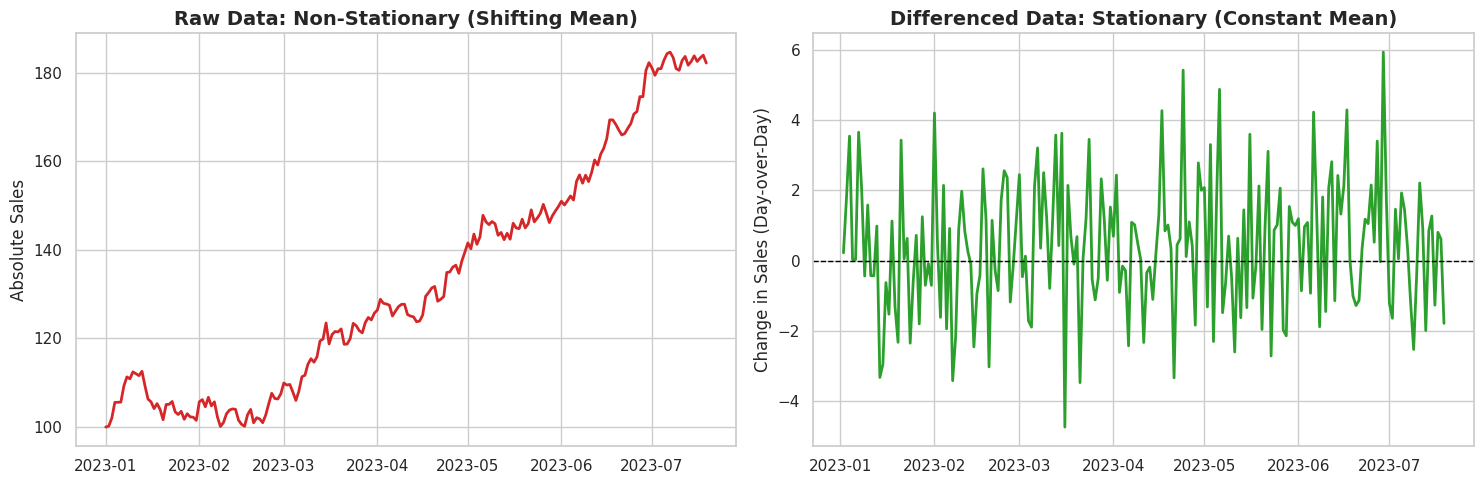

In [2]:
# 1. Simulate Non-Stationary Data (Random Walk with Upward Drift)
np.random.seed(42)
n_steps = 200
# Starting at 100, drifting upward by 0.5 per step, plus random noise
drift = 0.5
noise = np.random.normal(0, 2, n_steps)
raw_data = np.zeros(n_steps)
raw_data[0] = 100

for t in range(1, n_steps):
    raw_data[t] = raw_data[t-1] + drift + noise[t]

df = pd.DataFrame({'Sales': raw_data}, index=pd.date_range('2023-01-01', periods=n_steps))

# 2. Run the ADF Test on the Raw Data
def run_adf_test(series, title):
    result = adfuller(series.dropna())
    p_value = result[1]
    print(f"--- ADF Test: {title} ---")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"P-Value:        {p_value:.4f}")
    if p_value < 0.05:
        print("🚨 Result: STATIONARY (Safe to model)\n")
    else:
        print("❌ Result: NON-STATIONARY (Do not model this)\n")

run_adf_test(df['Sales'], "Raw Sales Data")

# 3. Apply First-Order Differencing
# The .diff() method calculates: Row[t] - Row[t-1]
df['Sales_Diff_1'] = df['Sales'].diff()

# 4. Run the ADF Test on the Differenced Data
run_adf_test(df['Sales_Diff_1'], "First-Order Differenced Sales")

# 5. Matplotlib Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Raw Data
axes[0].plot(df.index, df['Sales'], color='#d62728', linewidth=2)
axes[0].set_title("Raw Data: Non-Stationary (Shifting Mean)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Absolute Sales")

# Plot Differenced Data
axes[1].plot(df.index, df['Sales_Diff_1'], color='#2ca02c', linewidth=2)
# Add a horizontal line at 0 to show the stable mean
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Differenced Data: Stationary (Constant Mean)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Change in Sales (Day-over-Day)")

plt.tight_layout()
plt.show()

*(Insight: Look at the raw data on the left. If you ask an algorithm "What is the average?", the answer depends entirely on which month you look at. The model will fail. Look at the green data on the right. The trend is completely gone. The mean is perfectly locked at +0.5 (our simulated drift). An algorithm can easily learn from this stable, flat signal!)*

# 5. Handling Variance with the Log Transform

Differencing fixes a shifting **Mean**. But what if the data violates rule #2: Constant **Variance**? (e.g., Multiplicative seasonality where the seasonal spikes get larger every year).

Differencing will not fix exploding variance. To fix variance, you must mathematically squash the data using a **Logarithmic Transformation** ($\log(y_t)$) *before* you difference it.

*(Enterprise Workflow: If data is multiplicative and trending $\rightarrow$ Log Transform it first $\rightarrow$ Then Difference it $\rightarrow$ Train Model $\rightarrow$ Make Prediction $\rightarrow$ Reverse Difference (Cumulative Sum) $\rightarrow$ Reverse Log (Exponential) $\rightarrow$ Deliver Forecast to Business).*

---

## Real-World Use Case or Analogy:

Think of Stationarity like **Measuring the Speed of a Car**:

* **Non-Stationary (Absolute Location)**: Your raw data is your physical mile marker on the highway (Mile 10, Mile 60, Mile 130). Your absolute location is constantly trending upward. If I ask a computer to predict your location tomorrow, it has to guess entirely new, massive numbers it has never seen before.
* **Stationary (Differenced Data)**: Instead of measuring your absolute location, I difference the data. I subtract your location at 1:00 PM from your location at 2:00 PM. I am now measuring your **Speed** (50 MPH, 70 MPH, 65 MPH).
* **The Intelligence**: Speed is *Stationary*. It hovers around a constant mean (e.g., 65 MPH). It is infinitely easier for an algorithm to predict that your speed tomorrow will be roughly 65 MPH, than it is to predict your exact absolute lat/long coordinates on the globe!

---